# Cannabis during Pregnancy 

In [ ]:
import sys
sys.path.append('../code/libs/')

%load_ext autoreload
%autoreload 2
import utils
import viz
import ios
import constants
import text as txtlib

In [2]:
import pandas as pd
import numpy as np

# Data
---

## Load tweets

In [3]:
DATA_PATH = '../data'
RESULTS_PATH = '../results'
PLOTS_PATH = '../plots'

In [17]:
df_tweets = utils.read_all_tweets(RESULTS_PATH, verbose=True)
df_tweets.rename(columns={'id':'tweet_id'}, inplace=True)
df_tweets.shape
# 23/03/2022 22:05:12 Loading data/tweets_all.pkl...
# (5391569, 43)

10/01/2025 20:43:32 Loading ../results/tweets_all.pkl...


(5391569, 43)

In [18]:
df_tweets.sample(5)

,tweet_id,text,author_id,conversation_id,created_at,in_reply_to_user_id,lang,possibly_sensitive,referenced_tweets_details,reply_settings,...,hour,time,date_hour,lon,lat,status,centroid,ccode,geo_info,geometry
2985281,314612669707591680,RT @GullyFaEver: @lxndo_keef ah lando lol .......,182889306,314612669707591680,2013-03-21 05:41:20,None,en,None,NaN,everyone,...,5,05:41:20,2013-03-21 5,NaN,NaN,None,None,NaN,None,POINT EMPTY
3468366,175971216916623360,@Dope_DickBrodie lol boo u cray u dnt need no ...,392130139,175971216916623360,2012-03-03 15:49:42,299715976,en,None,None,everyone,...,15,15:49:42,2012-03-03 15,NaN,NaN,None,None,NaN,None,POINT EMPTY
1392319,1040614225637462016,I’m all for weed but quit smoking that shit in...,1029741212,1040614225637462016,2018-09-14 14:52:19,None,en,None,None,everyone,...,14,14:52:19,2018-09-14 14,NaN,NaN,None,None,NaN,None,POINT EMPTY
1310437,1065970453993349120,"RT @NBATV: ""Hey, Mutombo. This one's for you b...",947639606798835712,1065970453993349120,2018-11-23 14:08:55,None,en,None,NaN,everyone,...,14,14:08:55,2018-11-23 14,NaN,NaN,None,None,NaN,None,POINT EMPTY
3899041,1399372060896399360,@___SLICK Cause then I hit baby blunt that’s w...,60492625,1399368568261824515,2021-05-31 14:27:53,57728954,en,None,NaN,everyone,...,14,14:27:53,2021-05-31 14,NaN,NaN,None,None,NaN,None,POINT EMPTY


In [19]:
df_tweets.groupby('lang').tweet_id.size().sort_values()

lang
sl           1
lt           1
hi           1
is           1
und          2
hu           3
ca           4
eu          13
cy          15
no          18
lv          18
tr          26
cs          28
da          38
vi          51
sv          66
pl         116
it         265
pt         272
fr         299
es         358
et         504
in         631
de         703
ht         772
nl        1910
tl        3951
en     5381502
Name: tweet_id, dtype: int64

## Load Authors

In [22]:
df_authors = utils.read_all_users(RESULTS_PATH, verbose=True)
df_authors.rename(columns={'id':'author_id'}, inplace=True)
df_authors.shape
# 02/02/2022 21:50:38 Loading data/users_all.pkl...
# (3305111, 8)

10/01/2025 20:47:02 Loading ../results/users_all.pkl...


(3305111, 8)

In [21]:
df_authors.sample(5)

,author_id,name,username,location,description,created_at,protected,verified
2542937,1648853960,Hajiyah,ChinooLX570,+1 +234 +492,"Counsellor, Shrink👫 Interior Decor👷Internation...",2013-08-05 22:40:11,None,False
591176,53939819,Emma Rachael Pullan,epullan,"Wakefield, England","ED consultant, RL doctor, CF coach, mum, wife ...",2009-07-05 16:08:40,None,False
2410863,1620812016,elise,_Brunette_Baby_,None,,2013-07-25 17:03:36,None,False
1357781,173372918,Chakiira Price,KikiBooh94,"Woodbury, MN","African American, Swedish, Finnish, and Native...",2010-08-01 06:19:20,None,False
1849949,93409634,Junelle Fernandes,Junellexo,In your room,IG: junellexo,2009-11-29 14:28:45,None,False


# Descriptive
---

## Tweets

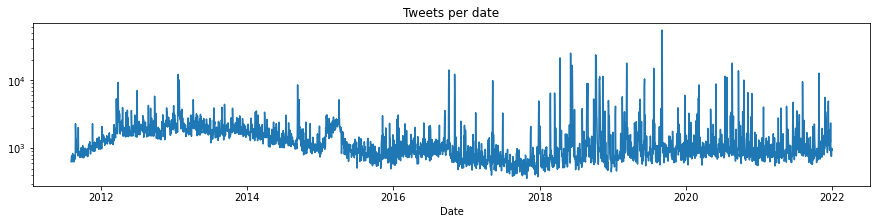

In [8]:
ax = df_tweets.rename(columns={'date':'Date'}).groupby('Date').tweet_id.size().plot(figsize=(15,3), 
                                                                                    title='Tweets per date', logy=True)

fn = ios.path_join(PLOTS_PATH, 'all_tweetsperday.pdf')
ax.figure.savefig(fn, bbox_inches='tight')

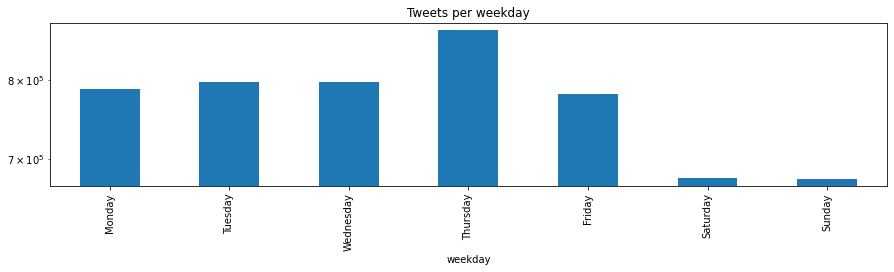

In [9]:
ax = df_tweets.groupby('weekday').tweet_id.size().plot.bar(figsize=(15,3), title='Tweets per weekday', logy=True)

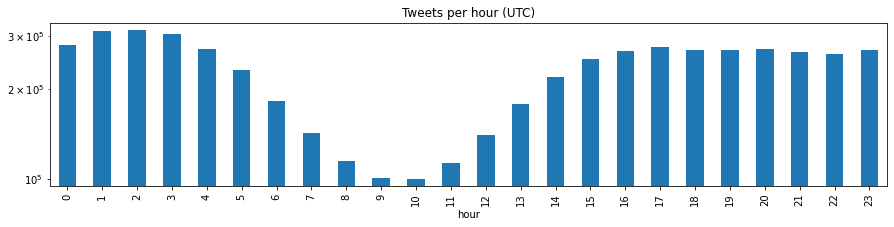

In [10]:
ax = df_tweets.groupby('hour').tweet_id.size().plot.bar(figsize=(15,3), title='Tweets per hour (UTC)', logy=True)

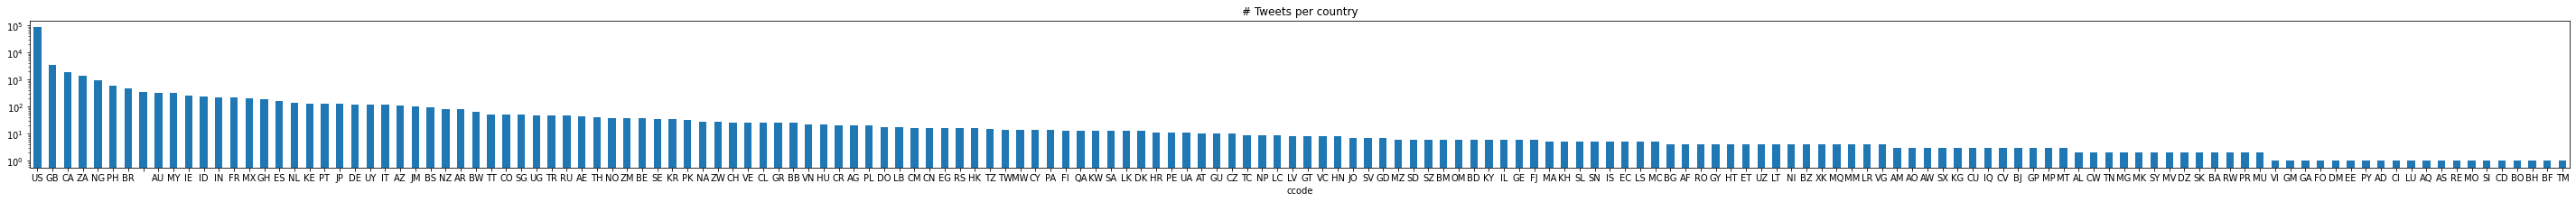

In [11]:
width = df_tweets.ccode.nunique()*0.3
ax = df_tweets.groupby('ccode').tweet_id.size().sort_values(ascending=False).plot.bar(figsize=(width,3), 
                                                                                      logy=True, rot=0, 
                                                                                      title='# Tweets per country')

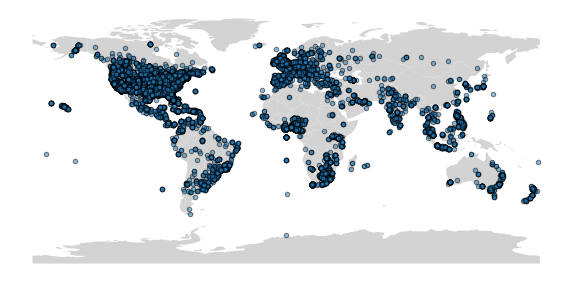

In [12]:
fn = ios.path_join(PLOTS_PATH, 'all_geotagged.pdf')
viz.plot_in_map(df_tweets, fn)

In [13]:
df_tweets.head()

,tweet_id,text,author_id,conversation_id,created_at,in_reply_to_user_id,lang,possibly_sensitive,referenced_tweets_details,reply_settings,...,hour,time,date_hour,lon,lat,status,centroid,ccode,geo_info,geometry
0,1417673516414013440,@loftmusik_ never been pregnant but if i were ...,2766734643,1417670748337065984,2021-07-21 02:31:20,373661218,en,None,NaN,everyone,...,2,02:31:20,2021-07-21 2,-92.131274,34.751936,None,POINT (-92.13127 34.75194),US,place,POINT (-92.13127 34.75194)
1,1417602329235361797,@maryxwetzel i (my pregnant self) smoke weed i...,2422554078,1417168782011899911,2021-07-20 21:48:27,1405005285933170692,en,None,NaN,everyone,...,21,21:48:27,2021-07-20 21,-82.669467,40.365160,None,POINT (-82.66947 40.36516),US,place,POINT (-82.66947 40.36516)
2,1416918506055081985,"@sbram94 Since birth, too? I was a single-foot...",166379492,1416916740655796225,2021-07-19 00:31:11,3426333339,en,None,NaN,everyone,...,0,00:31:11,2021-07-19 0,-68.984705,45.188407,None,POINT (-68.98470 45.18841),US,place,POINT (-68.98470 45.18841)
3,1416836524524539904,I don’t understand woman expecting baby(s) the...,64567001,1416836524524539904,2021-07-18 19:05:25,None,en,None,None,everyone,...,19,19:05:25,2021-07-18 19,-111.931711,34.168254,None,POINT (-111.93171 34.16825),US,place,POINT (-111.93171 34.16825)
4,1416325001356136454,Fuck if you please. If YOU please. I personall...,1337790916912947208,1416325001356136454,2021-07-17 09:12:49,None,en,None,None,everyone,...,9,09:12:49,2021-07-17 9,-83.099288,42.352786,None,POINT (-83.09929 42.35279),US,place,POINT (-83.09929 42.35279)


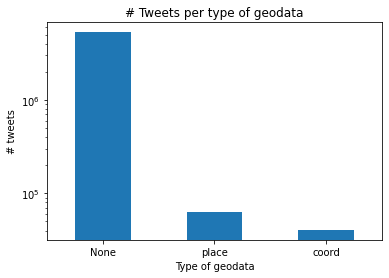

In [14]:
viz.plot_counts(df_tweets, 'geo_info', title='# Tweets per type of geodata', ylabel='# tweets', xlabel='Type of geodata', ylog=True)

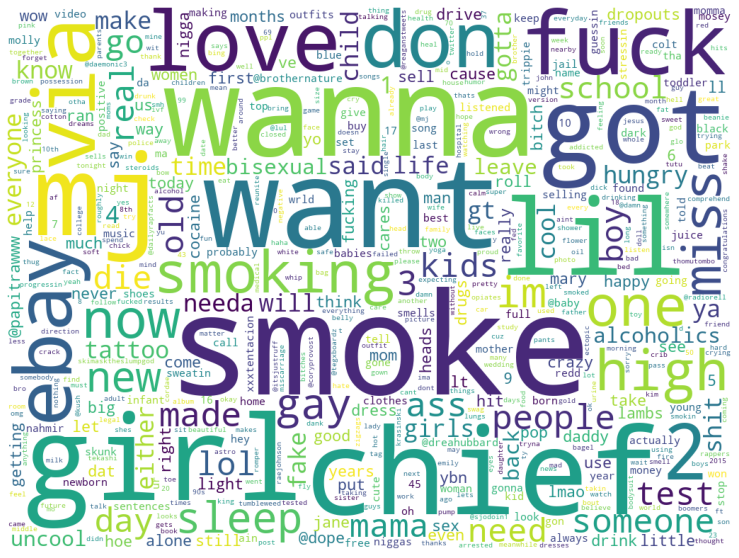

In [15]:
wc = txtlib.get_wordcloud(df_tweets, 'text', remove_keywords=True)
viz.plot_wordcloud(wc)

## Users

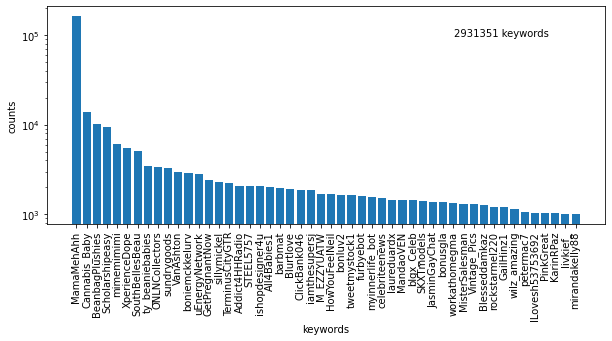

In [16]:
authors = txtlib.get_author_counts(df_tweets, df_authors)
viz.plot_keyword_count(authors, logy=True, topk=50)
# 2931351

## Entities

In [ ]:
keywords = txtlib.get_keyword_counts(df_tweets, 'text')
fn = ios.path_join(PLOTS_PATH, 'all_keywords.pdf')
viz.plot_keyword_count(keywords, logy=True, fn=fn)
# 46 keywords

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

df_tmp = pd.DataFrame(columns=['keyword','counts'])
for k,c in keywords:
    df_tmp = pd.concat([df_tmp,pd.DataFrame({'keyword':k,'counts':c},index=[1])])
df_tmp=df_tmp.reset_index(drop=True)

fig, ax = plt.subplots(1,1,figsize=(4,6))

# hide axes
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

ax.table(cellText=df_tmp.values, colLabels=df_tmp.columns, loc='center')
fig.tight_layout()

### save data as barplot
fn = ios.path_join(PLOTS_PATH, 'all_keywords_table.pdf')
fig.savefig(fn, bbox_inches='tight')
plt.close()

### save data as csv
fn = ios.path_join(RESULTS_PATH, 'all_keywords_counts.csv')
df_tmp.to_csv(fn)

In [59]:
unigrams = txtlib.get_unigrams(df_tweets, 'text')
viz.plot_grams(unigrams, topk=50)

In [60]:
bigrams = txtlib.get_bigrams(df_tweets, 'text')
viz.plot_grams(bigrams, topk=50)

In [61]:
hashtags = txtlib.get_hashtags(df_tweets, 'text')
viz.plot_grams(hashtags, topk=50)

In [62]:
mentions = txtlib.get_mentions(df_tweets, 'text')
viz.plot_grams(mentions, topk=50)

## Conventions

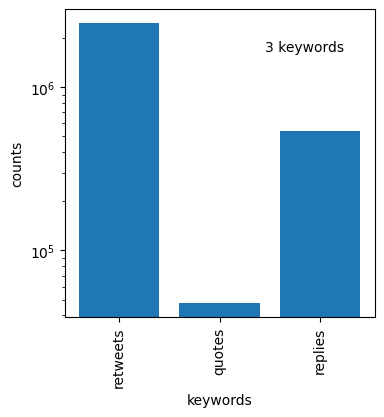

In [63]:
ntweets = {'retweets':0, 'quotes':0, 'replies':0}
ntweets['retweets'] = df_tweets.query("text.str.startswith('RT') or (retweeted != '[]' and retweeted.notna())").shape[0]
ntweets['quotes'] = df_tweets.query("quoted != '[]' and quoted.notna()").shape[0]
ntweets['replies'] = df_tweets.query("replied_to != '[]' and replied_to.notna()").shape[0]
viz.plot_keyword_count(ntweets, logy=True)
# 3 keywords

# Filtering

## Relevance of tweets

In [23]:
constants.SBERT_QUERIES

['cannabis during pregnancy',
 'smoking weed while pregnant',
 'the effects of cannabis on pregnant women',
 'smoking or consuming drugs during pregnancy',
 'the effects of cannabis on newborns',
 'kids, child and youth smoking cannabis',
 'medical cannabis for people',
 'legalization of cannabis']

In [24]:
## Tweets with SBERT scores
fn_sbert_tweets = ios.path_join(RESULTS_PATH, 'tweets_all_8clusters_mcs10_ss.pkl')
df_sbert = ios.read_pickle(fn_sbert_tweets)
df_sbert.rename(columns={'id':'tweet_id'}, inplace=True)
df_sbert.shape[0], round(df_sbert.shape[0]*100/df_tweets.shape[0])
# (2329552, 43%)

(2329552, 43)

In [11]:
df_sbert.head()

,tweet_id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,score_q8,total
0,1417673516414013440,2766734643,@loftmusik_ never been pregnant but if i were ...,0.732504,0.67069,0.760165,0.581427,0.681276,0.444975,0.526308,0.444595,4.841941
1,1417602329235361797,2422554078,@maryxwetzel i (my pregnant self) smoke weed i...,0.433795,0.577831,0.390623,0.492191,0.396159,0.437249,0.239965,0.279092,3.246906
2,1416918506055081985,166379492,"@sbram94 since birth, too? i was a single-foot...",0.559071,0.550456,0.511389,0.504051,0.512161,0.312145,0.30415,0.24937,3.502793
3,1416836524524539904,64567001,i don't understand woman expecting baby(s) the...,0.566753,0.646126,0.540336,0.534086,0.439238,0.288065,0.272889,0.273116,3.560609
4,1416325001356136454,1337790916912947208,fuck if you please. if you please. i personall...,0.150083,0.218912,0.130331,0.178675,0.089824,0.171981,0.127547,0.148167,1.215522


In [25]:
## Unique authors
df_sbert.author_id.nunique()
# 1384086

1384086

In [13]:
# stats for each sum of totals
df_relevant_thr = pd.DataFrame(columns=['min_total','n_tweets','n_unique_users'])
for thr in np.arange(0.0,2.0+0.1,0.1):
    tmp = df_sbert.query("total>@thr").copy()
    df_relevant_thr = pd.concat([df_relevant_thr, pd.DataFrame({'min_total':thr,'n_tweets':tmp.tweet_id.nunique(),'n_unique_users':tmp.author_id.nunique()}, index=[0])], ignore_index=True)
df_relevant_thr

,min_total,n_tweets,n_unique_users
0,0.0,2290064,1370559
1,0.1,2263514,1361914
2,0.2,2226602,1349601
3,0.3,2180020,1332601
4,0.4,2122655,1310138
5,0.5,2054112,1281401
6,0.6,1974834,1246458
7,0.7,1886070,1205104
8,0.8,1788045,1157446
9,0.9,1683249,1104364


In [26]:
# flag number of queries relevant
thresholds = {1:0.43, 2:0.48, 3:0.42, 4:0.42, 5:0.43}
df_sbert.loc[:,'n_valid_queries'] = df_sbert.apply(lambda row: sum([row[f"score_q{q}"]>thr for q,thr in thresholds.items()]),axis=1)
df_sbert.head()

,tweet_id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,score_q8,total,n_valid_queries
0,1417673516414013440,2766734643,@loftmusik_ never been pregnant but if i were ...,0.732504,0.67069,0.760165,0.581427,0.681276,0.444975,0.526308,0.444595,4.841941,5
1,1417602329235361797,2422554078,@maryxwetzel i (my pregnant self) smoke weed i...,0.433795,0.577831,0.390623,0.492191,0.396159,0.437249,0.239965,0.279092,3.246906,3
2,1416918506055081985,166379492,"@sbram94 since birth, too? i was a single-foot...",0.559071,0.550456,0.511389,0.504051,0.512161,0.312145,0.30415,0.24937,3.502793,5
3,1416836524524539904,64567001,i don't understand woman expecting baby(s) the...,0.566753,0.646126,0.540336,0.534086,0.439238,0.288065,0.272889,0.273116,3.560609,5
4,1416325001356136454,1337790916912947208,fuck if you please. if you please. i personall...,0.150083,0.218912,0.130331,0.178675,0.089824,0.171981,0.127547,0.148167,1.215522,0


In [27]:
df_sbert.groupby(['n_valid_queries'])[['tweet_id','author_id']].nunique().reset_index().rename(columns={'id':'n_tweets','author_id':'n_unique_users'})

,n_valid_queries,tweet_id,n_unique_users
0,0,1960421,1200490
1,1,75719,67966
2,2,48381,44006
3,3,49150,41395
4,4,65513,58782
5,5,130368,100287


In [28]:
# relevant tweets:
# before: 277.824
# then: 277.825 (n_valid_queries >= 1)
# now: 369.131 

min_thr_valid = 1
for id, row in df_sbert.query("n_valid_queries >= @min_thr_valid").sample(5).iterrows():
    print(id, row.corpus)
    print('---')
    
tmp_valid = df_sbert.query("n_valid_queries >= @min_thr_valid")
valid_tweets = tmp_valid.tweet_id.unique()
print(f"tweets: {tmp_valid.tweet_id.nunique()}, users: {tmp_valid.author_id.nunique()}")
print(tmp_valid.shape[0])

3446888 compared to david , t-roc , craig , and etc .... i'm just a new born baby when it comes to weed ...
---
1931546 oh you fucked up baby if they put the right amount of weed lol you not even suppose to eat a whole one 😯😯😂 url
---
299306 @juanadomains i don't follow. i support legalization. yes, there are irresponsible uses, including impaired driving, underage use, pregnant use, but the vast majority of cannabis use is responsible.
---
4935511 if i smoke this blunt baby i might forget about you
---
255156 cnn wrote an article entitled; 'using weed during pregnancy linked to psychotic-like behaviors in children, study finds' except their study didn't 'find' that at all. learn more below. url via @cannabis_net #cannabis #pregnancyweed
---
tweets: 369131, users: 276471
369131


In [17]:
# irrelevant tweets:
# before: 2.329.552
# then: 2.051.727 (n_valid_queries == 0)
# now: 1.960.421

thr_novalid = 0
for id, row in df_sbert.query("n_valid_queries == @thr_novalid").sample(5).iterrows():
    print(id, row.corpus)
    print('---')
    
tmp_invalid = df_sbert.query("n_valid_queries == @thr_novalid")
print(f"tweets: {tmp_invalid.tweet_id.nunique()}, users: {tmp_invalid.author_id.nunique()}")
print(tmp_invalid.shape[0])

3714643 @bravinyuri true.. kuna shit content. there's good content like this url dope artists like @daviekarr , elisha elai , etc but media ita air msee anaimba nonsense so sad.
---
4556604 i can't wait for her to find out stacey's having kush's baby
---
3477599 i dont judge but the all day weed smoking overly tatted, no education having high school dropout baby mama drama kinda guy just isnt my type
---
2108258 eating a pot of baby food for academic purposes url
---
1734700 baby i could be your superman or tarzan you could be my lil mary jane or louis lane url
---
tweets: 1960421, users: 1200490
1960421


## Bot accounts

In [29]:
fn_bots = ios.path_join(RESULTS_PATH, 'users_botometer.csv')
df_bots = ios.read_csv(fn_bots)
df_bots.rename(columns={'user':'author_id'}, inplace=True)
df_bots.shape
# (350674, 4)

(350674, 4)

In [30]:
df_bots.head(5)

,author_id,cap,raw,display
0,3020171467,0.792032,0.37,1.8
1,3787357817,0.419722,0.08,0.4
2,20563800,0.785221,0.33,1.6
3,2547515392,0.419722,0.08,0.4
4,153092097,0.802148,0.75,3.8


In [35]:
caps = [round(c,1) for c in np.arange(0.0,1.0+0.1,0.1)]
condition = '<='
min_caps = {min_cap:df_bots.query(f"cap {condition} @min_cap").shape[0] for min_cap in caps}

print("Number of potential humans:")
for k,v in min_caps.items():
    print(f"cap {condition} {k} = {v}")

Number of potential humans:
cap <= 0.0 = 15779
cap <= 0.1 = 15779
cap <= 0.2 = 15779
cap <= 0.3 = 80731
cap <= 0.4 = 139597
cap <= 0.5 = 168275
cap <= 0.6 = 196259
cap <= 0.7 = 226938
cap <= 0.8 = 320916
cap <= 0.9 = 344184
cap <= 1.0 = 350674


In [36]:
max_cap = 0.8
df_bots.loc[:,'valid_user'] = df_bots.cap.apply(lambda c: c<=max_cap)
df_bots.sample(5)

,author_id,cap,raw,display,valid_user
96906,797505756568260612,0.226318,0.01,0.0,True
35120,508126549,0.447947,0.09,0.4,True
222123,236793421,0.000000,0.00,0.0,True
60396,1044025712859107328,0.306188,0.04,0.2,True
2006,788212038656851968,0.306188,0.04,0.2,True


In [37]:
df_bots.query("cap>@max_cap").shape[0], df_bots.query("cap<=@max_cap").shape[0]

(29758, 320916)

In [38]:
df_bots.groupby('valid_user').size()

# valid_user
# False     29758
# True     320916
# dtype: int64

valid_user
False     29758
True     320916
dtype: int64

In [39]:
valid_authors = df_bots.query('valid_user == True').author_id.unique()
tmp_valid = df_sbert.query("author_id in @valid_authors")
print(f"tweets: {tmp_valid.tweet_id.nunique()}, users: {tmp_valid.author_id.nunique()}")
print(tmp_valid.shape[0])

# tweets: 663136, users: 320916
# 663136

tweets: 663136, users: 320916
663136


In [41]:
tmp_valid = df_sbert.query("author_id in @valid_authors and tweet_id in @valid_tweets")
print(f"tweets: {tmp_valid.tweet_id.nunique()}, users: {tmp_valid.author_id.nunique()}")
print(tmp_valid.shape[0])

# tweets: 305524, users: 240881
# 305524

tweets: 305524, users: 240881
305524


# Geo-location

## Tweets

In [42]:
fn_gtweets = ios.path_join(RESULTS_PATH, 'tweets_valid_geo.pkl')
df_geo_tweets = ios.read_pickle(fn_gtweets)
df_geo_tweets.shape
# (102112, 58)

(102112, 58)

In [43]:
df_geo_tweets.head(5)

,tweet_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,score_q8,...,status,centroid,ccode,geo_info,geometry,country,postcode,state,neighborhood,year
0,1417673516414013440,@loftmusik_ never been pregnant but if i were ...,0.732504,0.67069,0.760165,0.581427,0.681276,0.444975,0.526308,0.444595,...,None,POINT (-92.13127 34.75194),US,place,POINT (-92.13127 34.75194),NaN,NaN,NaN,NaN,2021
1,1416918506055081985,"@sbram94 since birth, too? i was a single-foot...",0.559071,0.550456,0.511389,0.504051,0.512161,0.312145,0.30415,0.24937,...,None,POINT (-68.98470 45.18841),US,place,POINT (-68.98470 45.18841),NaN,NaN,NaN,NaN,2021
2,1416836524524539904,i don't understand woman expecting baby(s) the...,0.566753,0.646126,0.540336,0.534086,0.439238,0.288065,0.272889,0.273116,...,None,POINT (-111.93171 34.16825),US,place,POINT (-111.93171 34.16825),NaN,NaN,NaN,NaN,2021
3,1411821804004560898,"to each it's own, but idc what anybody tells m...",0.590113,0.673205,0.582265,0.530949,0.464752,0.473853,0.440655,0.448171,...,None,POINT (-92.13127 34.75194),US,place,POINT (-92.13127 34.75194),NaN,NaN,NaN,NaN,2021
4,1408872135267848195,i loved weed ever since i was 15. i got pregna...,0.570017,0.6336,0.542046,0.489281,0.528671,0.520865,0.49408,0.421909,...,None,POINT (-83.09929 42.35279),US,place,POINT (-83.09929 42.35279),NaN,NaN,NaN,NaN,2021


## Users

In [44]:
fn_gusers = ios.path_join(RESULTS_PATH, 'users_valid_geo.pkl')
df_geo_users = ios.read_pickle(fn_gusers)
df_geo_users.rename(columns={'user_id':'author_id'}, inplace=True)
df_geo_users.shape
# (82697, 22)

(82697, 22)

In [45]:
df_geo_users.head(5)

,author_id,name,username,location,description,created_at,protected,verified,cap,raw,...,loc_source,ccode,country,postcode,state,city,neighborhood,lat,lon,centroid
0,2766734643,cheyenne⛈,chyxendi,the USA unfortunately,20. capricorn. child advocate. nazi feminist. ...,2014-09-11 00:12:24,None,False,0.278726,0.03,...,tweets,US,United States,None,Arkansas,None,NaN,34.75,-92.13,POINT (-92.13000 34.75000)
1,166379492,Merry Stephanie 🎄,JetaimeLesMis,"Savannah, GA",RI➡️FL➡️GA. NE Patriots fan for LIFE; kicking ...,2010-07-14 00:49:06,None,False,0.306188,0.04,...,tweets,US,United States,None,Maine,None,NaN,45.19,-68.98,POINT (-68.98000 45.19000)
2,64567001,Yazmin💋,Chef_Hernandezz,None,"Mom of 3 ❤️ TATTOOS 🖋 I'm a rebel, Idgaf. 🇲🇽#G...",2009-08-11 00:25:21,None,False,0.391216,0.07,...,tweets,US,United States,None,Arizona,None,NaN,34.17,-111.93,POINT (-111.93000 34.17000)
3,1703246233,jordan,JPOWW_,AR,❤️‍🔥,2013-08-26 23:41:48,None,False,0.475677,0.10,...,tweets,US,United States,None,Arkansas,None,NaN,34.75,-92.13,POINT (-92.13000 34.75000)
4,28005694,Bush Of Wall Street,Titties4Sale,Detroit Dirty Glove,31af. Tryna get Boston George and Diego money....,2009-04-01 00:26:00,None,False,0.577886,0.14,...,tweets,US,United States,None,Michigan,Detroit,NaN,42.35,-83.10,POINT (-83.10000 42.35000)


In [49]:
df_geo_users[['location', 'loc_source', 'ccode', 'country', 'state', 'lon', 'lat', 'centroid', 'geometry']].sample(20)

,location,loc_source,ccode,country,state,lon,lat,centroid,geometry
8600,Delware News Journal,NaN,None,None,None,NaN,NaN,None,None
54878,None,NaN,None,None,None,NaN,NaN,None,None
8184,"Oklahoma, USA",bio,US,United States,Oklahoma,-97.268410,34.955082,POINT (-97.26841 34.95508),POINT (-97.26841 34.95508)
8699,None,NaN,None,None,None,NaN,NaN,None,None
82479,Atlanta Ga,bio,US,United States,Georgia,-84.390266,33.748993,POINT (-84.39027 33.74899),POINT (-84.39027 33.74899)
9766,W/Lj,bio,IR,Iran,استان آذربایجان غربی,45.767216,36.903225,POINT (45.76722 36.90322),POINT (45.76722 36.90322)
53235,"Midwest, USA ⚫️🟢",bio,US,United States,Wyoming,-106.280075,43.411392,POINT (-106.28008 43.41139),POINT (-106.28008 43.41139)
46945,C-137,NaN,None,None,None,NaN,NaN,None,None
21522,with my sugah daddy,NaN,None,None,None,NaN,NaN,None,None
70368,None,NaN,None,None,None,NaN,NaN,None,None


# Final corpus

In [82]:
df_sbert.shape[0], df_geo_tweets.shape[0], df_geo_users.shape[0], df_bots.shape[0]
# (2329552, 102112, 82697, 350674)

(2329552, 102112, 82697, 350674)

In [83]:
# add tweet metadata
tcols = ['tweet_id', 'text', 'created_at','retweet_count','reply_count','like_count','quote_count','mentions','replied_to','quoted','retweeted','urls','hashtags']
df_merged = df_sbert.merge(df_tweets[tcols], on='tweet_id', how='left').copy()

# add tweet geo
gtcols = ['tweet_id', 'ccode', 'geo_info', 'geometry', 'lon', 'lat'] #point(lon,lat)
df_merged = df_merged.merge(df_geo_tweets[gtcols], on='tweet_id', how='left').copy()

# add author metadata
acols = ['author_id','location','description','created_at','verified'] 
df_merged = df_merged.merge(df_authors[acols], on='author_id', how='left', suffixes=('_t','_a')).copy()

# add author botometer
gbcols = ['author_id', 'cap', 'valid_user']
df_merged = df_merged.merge(df_bots[gbcols], on='author_id', how='left').copy()

# author geo
gacols = ['author_id','loc_source','ccode','geometry','lon','lat']
df_merged = df_merged.merge(df_geo_users[gacols], on='author_id', how='left', suffixes=('_t','_a')).copy()

df_merged.shape
# (2329552, 17)
# (2329552, 36)
# (2329552, 37)

(2329552, 41)

In [84]:
df_merged.head(5)

,tweet_id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,...,description,created_at_a,verified,cap,valid_user,loc_source,ccode_a,geometry_a,lon_a,lat_a
0,1417673516414013440,2766734643,@loftmusik_ never been pregnant but if i were ...,0.732504,0.67069,0.760165,0.581427,0.681276,0.444975,0.526308,...,20. capricorn. child advocate. nazi feminist. ...,2014-09-11 00:12:24,False,0.278726,True,tweets,US,POINT (-92.13000 34.75000),-92.13,34.75
1,1417602329235361797,2422554078,@maryxwetzel i (my pregnant self) smoke weed i...,0.433795,0.577831,0.390623,0.492191,0.396159,0.437249,0.239965,...,homebody 🍂,2014-04-01 19:16:20,False,0.000000,True,NaN,NaN,None,NaN,NaN
2,1416918506055081985,166379492,"@sbram94 since birth, too? i was a single-foot...",0.559071,0.550456,0.511389,0.504051,0.512161,0.312145,0.30415,...,RI➡️FL➡️GA. NE Patriots fan for LIFE; kicking ...,2010-07-14 00:49:06,False,0.306188,True,tweets,US,POINT (-68.98000 45.19000),-68.98,45.19
3,1416836524524539904,64567001,i don't understand woman expecting baby(s) the...,0.566753,0.646126,0.540336,0.534086,0.439238,0.288065,0.272889,...,"Mom of 3 ❤️ TATTOOS 🖋 I'm a rebel, Idgaf. 🇲🇽#G...",2009-08-11 00:25:21,False,0.391216,True,tweets,US,POINT (-111.93000 34.17000),-111.93,34.17
4,1416325001356136454,1337790916912947208,fuck if you please. if you please. i personall...,0.150083,0.218912,0.130331,0.178675,0.089824,0.171981,0.127547,...,A Public JournaL by ATIENO. an Expatriate. a T...,2020-12-12 16:06:36,False,0.803671,False,NaN,NaN,None,NaN,NaN


In [86]:
FN_FULL_CORPUS = 'full_corpus_2M_merged_tweets_users'

In [87]:
fn = ios.path_join(RESULTS_PATH, f'{FN_FULL_CORPUS}.csv')
ios.save_csv(df_merged, fn)

In [88]:
fn = ios.path_join(RESULTS_PATH, f'{FN_FULL_CORPUS}.pkl')
ios.write_pickle(df_merged, fn)

In [89]:
FN_VALID_CORPUS = 'valid_corpus_305K_merged_tweets_users'
df_valid = df_merged.query("author_id in @valid_authors and tweet_id in @valid_tweets").copy()
df_valid.shape

(305524, 41)

In [90]:
fn = ios.path_join(RESULTS_PATH, f'{FN_VALID_CORPUS}.csv')
ios.save_csv(df_valid, fn)

In [91]:
fn = ios.path_join(RESULTS_PATH, f'{FN_VALID_CORPUS}.pkl')
ios.write_pickle(df_valid, fn)

## Final "valid" corpus (ICWSM)

In [92]:
import os
import glob
OUTPUT_DIR = '../results/ICWSM'
PLOTS_DIR = os.path.join(OUTPUT_DIR, 'plots')
DPI = 300

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd
from shapely import wkt


In [94]:
import sys
sys.path.append('helpers')

%load_ext autoreload
%autoreload 2

import census as cn
import geo

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
sns.reset_defaults()
plt.rcdefaults()

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_context("paper", font_scale=1.6, rc=custom_params)

In [96]:
NONE = ['',' ',None,'none','na',np.nan]

In [97]:
FN_FINAL_CORPUS = 'final_corpus_74K_merged_tweets_users_valid'
fn = ios.path_join(RESULTS_PATH, f"{FN_FINAL_CORPUS}.pkl")

In [98]:
if ios.exists(fn):
    print('loading...')
    df_merged_final_corpus_valid_tag = ios.read_pickle(fn)
    print(df_merged_final_corpus_valid_tag.shape)
    
else:
    df_merged_final_corpus_valid_tag = df_merged.query("tweet_id in @valid_tweets and author_id in @valid_authors and geometry_a not in @NONE").copy()
    print(df_merged_final_corpus_valid_tag.shape)
    
    df_merged_final_corpus_valid_tag.loc[:,'country'] = df_merged_final_corpus_valid_tag.ccode_a.apply(lambda x: x if x in ['US','CA'] else 'Others')
    df_merged_final_corpus_valid_tag.loc[:,'year_t'] = df_merged_final_corpus_valid_tag.created_at_t.dt.year
    print(df_merged_final_corpus_valid_tag.shape)
    
    
    print('saving...')
    fn = ios.path_join(RESULTS_PATH, f'{FN_FINAL_CORPUS}.csv')
    ios.save_csv(df_merged_final_corpus_valid_tag, fn)

    fn = ios.path_join(RESULTS_PATH, f'{FN_FINAL_CORPUS}.pkl')
    ios.write_pickle(df_merged_final_corpus_valid_tag, fn)
    
    # (73891, 36)
    # (73891, 38)

(73891, 41)
(73891, 43)
saving...


In [99]:
df_merged_final_corpus_valid_tag.head(5)

,tweet_id,author_id,corpus,score_q1,score_q2,score_q3,score_q4,score_q5,score_q6,score_q7,...,verified,cap,valid_user,loc_source,ccode_a,geometry_a,lon_a,lat_a,country,year_t
0,1417673516414013440,2766734643,@loftmusik_ never been pregnant but if i were ...,0.732504,0.67069,0.760165,0.581427,0.681276,0.444975,0.526308,...,False,0.278726,True,tweets,US,POINT (-92.13000 34.75000),-92.13,34.75,US,2021
2,1416918506055081985,166379492,"@sbram94 since birth, too? i was a single-foot...",0.559071,0.550456,0.511389,0.504051,0.512161,0.312145,0.30415,...,False,0.306188,True,tweets,US,POINT (-68.98000 45.19000),-68.98,45.19,US,2021
3,1416836524524539904,64567001,i don't understand woman expecting baby(s) the...,0.566753,0.646126,0.540336,0.534086,0.439238,0.288065,0.272889,...,False,0.391216,True,tweets,US,POINT (-111.93000 34.17000),-111.93,34.17,US,2021
7,1411821804004560898,1703246233,"to each it's own, but idc what anybody tells m...",0.590113,0.673205,0.582265,0.530949,0.464752,0.473853,0.440655,...,False,0.475677,True,tweets,US,POINT (-92.13000 34.75000),-92.13,34.75,US,2021
10,1408872135267848195,28005694,i loved weed ever since i was 15. i got pregna...,0.570017,0.6336,0.542046,0.489281,0.528671,0.520865,0.49408,...,False,0.577886,True,tweets,US,POINT (-83.10000 42.35000),-83.10,42.35,US,2021
